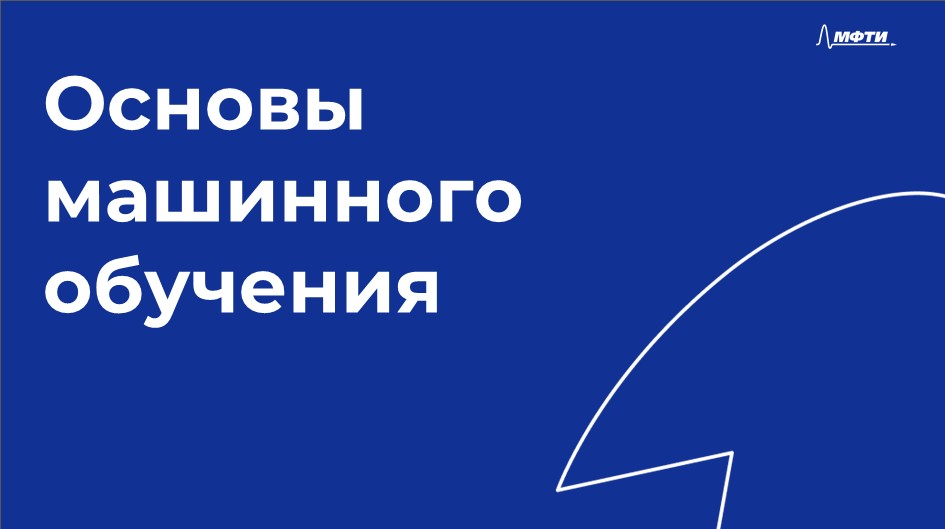

# 🎯 Неделя 2. Семинар 2.

**Сегодня в программе:**
1. Полиномиальная регрессия.
2. Переобучение и недообучение.
3. Регуляризация.

In [1]:
# !pip install phik

In [2]:
from phik.report import plot_correlation_matrix
from phik import phik_matrix

<frozen importlib._bootstrap>:488: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'phik.lib._phik_simulation_core', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score

In [4]:
import warnings
warnings.filterwarnings("ignore")

## 🟢 1. Полиномиальная регрессия




Полиномиальная регрессия (Polynomial Regression) — это более сложная и нелинейная модель. Вместо уравнения прямой используется **уравнение полинома (многочлена)**, который отражает определённую степенную зависимость. *Основное правило: чем больше степень, тем сложнее модель.*

В простом двумерном случае, когда мы рассматриваем зависимость целевого признака от одного фактора, полиномом второй степени будет уравнение параболы:

$$y = k_1 x + k_2 x^2 + b$$


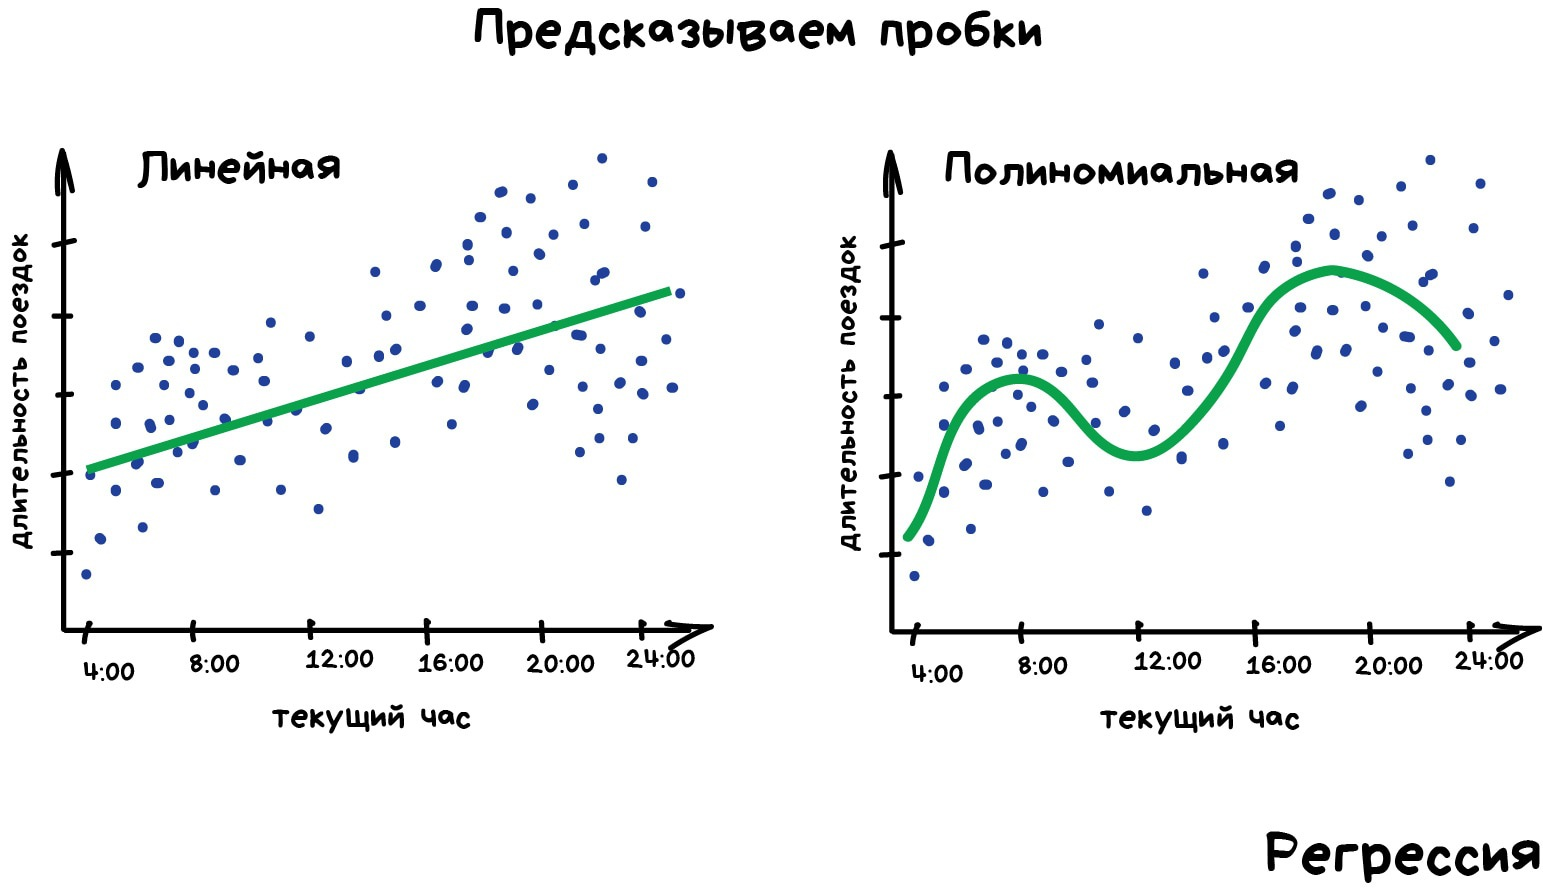

Когда факторов больше одного, например два, то, помимо возведения фактора в квадрат, появляются ещё и комбинации из x1 и x2:


$$\hat{y}=k_{1} x_{1}+k_{2} x_{1}^{2}+k_{3} x_{2}+k_{4} x^{2}_{2}+k_{5} x_{1} x_{2} + b$$


Такая модель описывает сложную поверхность в трёхмерном пространстве, которая представлена на рисунке:




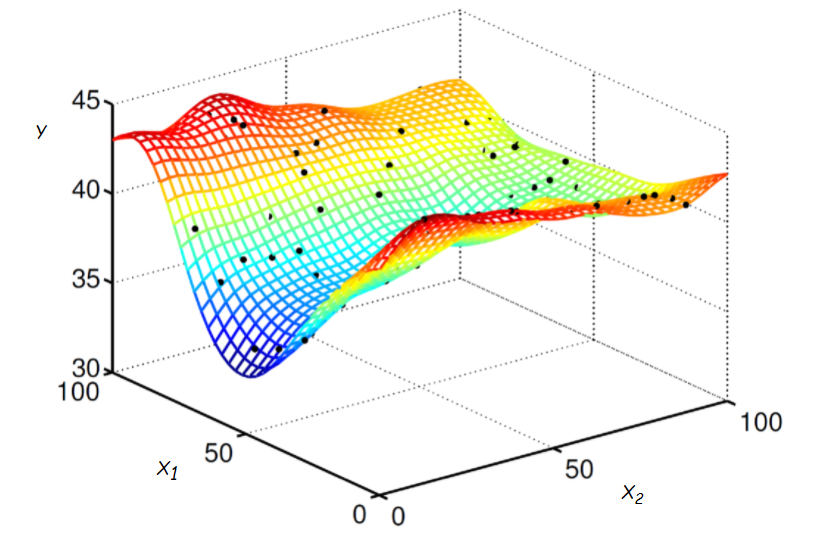

Количество коэффициентов очень быстро растёт при увеличинении числа факторов - а вместе с этим и сложность модели.






Степени  можно тоже считать своего рода искусственными признаками в данных. Они называются полиномиальными признаками.

Поэтому полиномиальная регрессия — это та же линейная регрессия, просто с новыми признаками. На деле выглядит как один из методов FeatureEngineering.


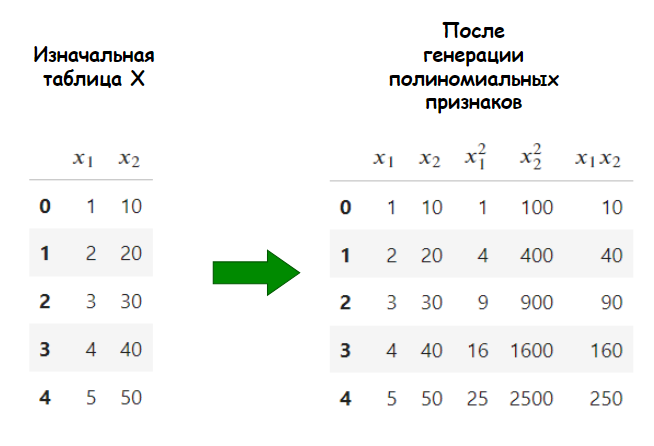

Благодаря степенным слагаемым модель становится сложнее и начинает улавливать более сложные зависимости и выдавать меньшее смещение.


В реальной практике, как правило, используется полином второй (максимум третьей) степени. Чем выше степень полинома, тем больше слагаемых - а значит, тем больше признаков и тем сложнее модель.





Снова поработаем с датасетом про дома, для начала посмотрим на качество обычной линейной регрессии:

In [5]:
# снова поработаем с датасетом про дома
data = fetch_openml(name='house_sales')
print(data.DESCR)

**Author**: https://www.kaggle.com/harlfoxem/  
https://www.kaggle.com/harlfoxem/  
**Source**: [original](https://www.kaggle.com/harlfoxem/housesalesprediction) - 2016-08-25  
**Please cite**:   

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

It contains 19 house features plus the price and the id columns, along with 21613 observations.
It's a great dataset for evaluating simple regression models.

* Id: Unique ID for each home sold
* Date: Date of the home sale
* Price: Price of each home sold
* Bedrooms: Number of bedrooms
* Bathrooms: Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* Sqft_living: Square footage of the apartments interior living space
* Sqft_lot: Square footage of the land space
* Floors: Number of floors
* Waterfront: A dummy variable for whether the apartment was overlooking the waterfront or not
* View: An index from 0 to 4 of how good the view 

In [6]:
df = data.data
print(df.shape)
df.head()

(21613, 20)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
df = data.data.drop(['date', 'zipcode', 'lat', 'long', 'yr_renovated'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('price', axis=1).values, df['price'].values, random_state=42
)

# не забываем масштабировать!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

print(f"Train R^2: {r2_score(y_train, y_train_predict)}")
print(f"Test R^2: {r2_score(y_test, y_test_predict)}")

Train R^2: 0.6512451885252661
Test R^2: 0.6591471618009244


При реализации полиномиальной регрессии стоит проводить масштабирование **перед** генерацией полиномиальных признаков.

Это улучшает качество модели и обеспечивает более стабильные результаты при обучении.

Если делать масштабирование после создания полиномов, то:

- Значения новых признаков могут значительно варьироваться. Стандартизация этих полиномов может сделать интерпретацию коэффициентов модели более сложной.

- Модель станет более чувствительной к выбросам и шуму в данных. Поскольку полиномиальные признаки могут иметь большие значения, их стандартизация может не устранить проблемы, а наоборот, усугубить их.


In [10]:
class PolynomialFeatures2:
    """
    Генератор полиномиальных фичей степени 2
    """

    def fit(self, X):
        # Как получить число признаков автоматически?
        self.n_features_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.array(X)
        # Как получить число объектов автоматически?
        n_samples = X.shape[0]
        poly_features = [X]  # исходные признаки

        # квадраты
        poly_features.append(X ** 2)

        # попарные произведения
        for i in range(self.n_features_):
            for j in range(i + 1, self.n_features_):
                poly_features.append((X[:, i] * X[:, j]).reshape(n_samples, 1))

        return np.hstack(poly_features)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [11]:
# Генерация фичей
poly = PolynomialFeatures2()
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [12]:
# Модель
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_predict = model.predict(X_train_poly)
y_test_predict = model.predict(X_test_poly)

print(f"Train R^2: {r2_score(y_train, y_train_predict)}")
print(f"Test R^2: {r2_score(y_test, y_test_predict)}")

Train R^2: 0.7510597208143782
Test R^2: 0.7066856167839025


Чтобы построить полиномиальную регрессиию в sklearn, необходимо создать полиномиальные признаки с помощью объекта класса [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) из модуля preprocessing. Это преобразователь, который позволит сгенерировать полиномиальные признаки любой степени и добавить их в таблицу. У класса есть 2 основных параметра:

- `degree` — степень полинома, по умолчанию используется степень 2.
- `include_bias` — включать ли в результирующую таблицу столбец из единиц (x в степени 0), который соответствует свободному члену в модели. По умолчанию стоит `True`, но лучше выставить его в значение `False`, т.к. линейные модели в sklearn по умолчанию подразумевают смещение (intercept).


Для того чтобы обучить модель мы так же используем метод fit(), а чтобы сгенерировать новую таблицу признаков, в которую будут включены полиномиальные признаки, используется метод transform(), в который нужно передать выборки:

In [13]:
# Создаем генератор полиномиальных признаков
poly = PolynomialFeatures(degree=2, include_bias=False)

poly.fit(X_train)

# Генерируем полиномиальные признаки для тренировочной выборки
X_train_poly = poly.transform(X_train)

# Генерируем полиномиальные признаки для тестовой выборки
X_test_poly = poly.transform(X_test)

In [14]:
len(X_train_poly[0])

119

Теперь передаём полученные данные модели линейной регрессии, чтобы найти коэффициенты полинома по МНК-алгоритму:



In [15]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

y_train_predict = model.predict(X_train_poly)
y_test_predict = model.predict(X_test_poly)

print(f"Train R^2: {r2_score(y_train, y_train_predict)}")
print(f"Test R^2: {r2_score(y_test, y_test_predict)}")

Train R^2: 0.7510597208143782
Test R^2: 0.7066856167839022


## 🟢 2. Переобучение и недообучение

Обсудим две очень важные проблемы обучения всех моделей ML - это **переобучение** и **недообучение**. Их названия достаточно полно описывают их суть, но давайте подробно разберёмся в причинах их возникновения.



### Недообучение
Недообучение - это ситуация, когда модель по тем или иным причинам не смогла обобщить закономерности в данных и выучить необходимые зависимости.



Сгенерируем случайные данные с нелинейной зависимостью, которые можно описать полиномом 3 степени:

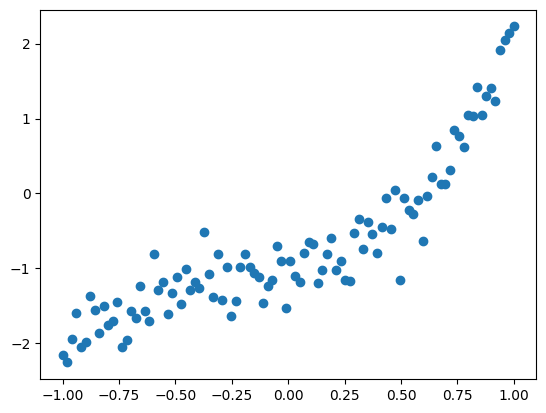

In [16]:
np.random.seed(42)
x_data = np.linspace(-1, 1, 100)
y_data = np.polyval([2, 1, 0.3, -1], x_data) + np.random.randn(x_data.shape[0]) * 0.3 # добавим шум

plt.scatter(x_data, y_data)

В данном случае требуется смоделировать поведение полинома 3 степени. Что получится, если мы попробуем построить линейную регрессию?

In [17]:
# Преобразование данных для регрессии
x_data_reshaped = x_data.reshape(-1, 1)
x_data_reshaped.shape

(100, 1)

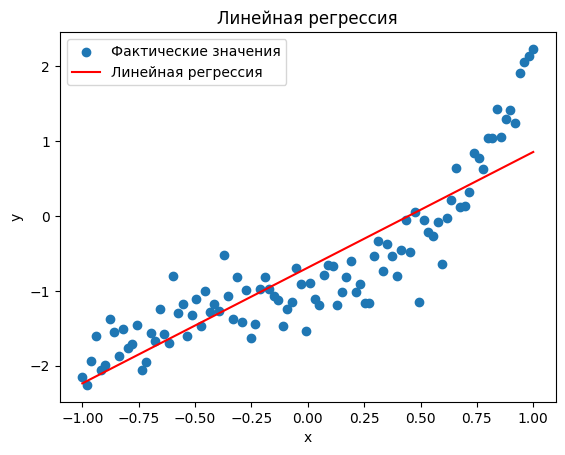

In [18]:
linear_model = LinearRegression()
linear_model.fit(x_data_reshaped, y_data)

# Предсказания линейной регрессии
y_pred_linear = linear_model.predict(x_data_reshaped)

# Визуализация линейной регрессии
plt.scatter(x_data, y_data, label='Фактические значения')
plt.plot(x_data, y_pred_linear, color='red', label='Линейная регрессия')
plt.title('Линейная регрессия')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

Очевидно, что линейная регрессия с этой задачей не справляется. Всё дело в том, что этой модели банально не хватает параметров для того, чтобы смоделировать такую сложную зависимость. Это один из возможных примеров ситуации **недообучения**.

Решение этой проблемы обычно довольно простое - достаточно взять более сложную модель с большим числом параметров.

Если в приведенном примере мы увеличим число параметров, заменив линейную регрессию полиномиальной регрессией третьей степени, мы без труда решим поставленную задачу с достаточно высокой точностью.

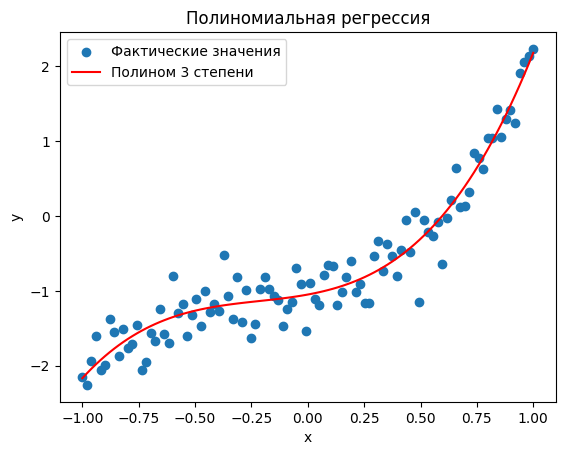

In [19]:
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)

x_train_3 = poly_features_3.fit_transform(x_data_reshaped)

poly_model_3 = LinearRegression()
poly_model_3.fit(x_train_3, y_data)

# Предсказания полиномиальной регрессии
y_pred_poly_3 = poly_model_3.predict(x_train_3)

# Визуализация полиномиальной регрессии
plt.scatter(x_data, y_data, label='Фактические значения')
plt.plot(x_data, y_pred_poly_3, color='red', label='Полином 3 степени')
plt.title('Полиномиальная регрессия')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

### Переобучение

Проблема переобучения более сложная и комплексная, чем проблема недообучения.

Если недообучение связано с недостаточной сложностью выбранной модели, то переобучение следует из **избыточной сложности**. Вопреки ожиданиям, слишком сложная модель также неспособна выучить нужные зависимости в данных. Но она с высокой вероятностью выучит зависимости в данных, которые там появились по чистой случайности и не являются естественными для нашей задачи.

Другой распространённой причиной проблемы переобучения является **недостаток данных** - на самом деле, в некоторых случаях он может быть скомпенсиррован уменьшением сложности модели.

Ранее мы смоделировали многочлен третьей степени слишком простой моделью, то есть линейной регрессией. Она плохо справилась с задачей. Очевидно, что и полином второй степени вряд ли справится с этой задачей хорошо, ведь исходные данные смоделированны при помощи полиномиальной зависимости третьей степени.

А что если взять полином 4 степени в качестве модели? А 5? Может быть, 30 степени? Ведь каждый из них может моделировать и зависимости меньших порядков, то есть в теории полином 30 степени должен также хорошо справиться с задачей, как и полинном 3 степени, а может даже лучше.

Проверим, так ли это:

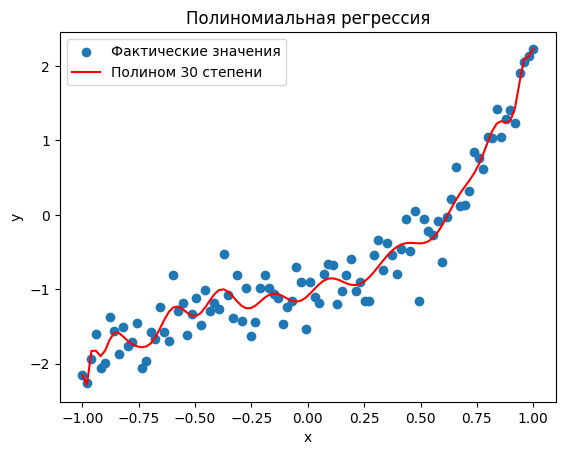

In [20]:
poly_features_30 = PolynomialFeatures(degree=30, include_bias=False)

x_train_30 = poly_features_30.fit_transform(x_data_reshaped)

poly_model_30 = LinearRegression()
poly_model_30.fit(x_train_30, y_data)

# Предсказания полиномиальной регрессии
y_pred_poly_30 = poly_model_30.predict(x_train_30)

# Визуализация полиномиальной регрессии
plt.scatter(x_data, y_data, label='Фактические значения')
plt.plot(x_data, y_pred_poly_30, color='red', label='Полином 30 степени')
plt.title('Полиномиальная регрессия')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

А теперь проверим качество всех вариантов.

Сначала на трейне:

In [21]:
r2_linear_train = r2_score(y_data, y_pred_linear)
r2_poly_3_train = r2_score(y_data, y_pred_poly_3)
r2_poly_30_train = r2_score(y_data, y_pred_poly_30)

print(f'Линейная модель, R^2: {r2_linear_train:.4f}')
print(f'Полиномиальная модель (3 степени), R^2: {r2_poly_3_train:.4f}')
print(f'Полиномиальная модель (30 степени), R^2: {r2_poly_30_train:.4f}')

Линейная модель, R^2: 0.7748
Полиномиальная модель (3 степени), R^2: 0.9336
Полиномиальная модель (30 степени), R^2: 0.9453


А теперь на тесте:

In [22]:
# Генерация тестовых данных
x_data_test = np.linspace(-1, 1, 100)  # Используем тот же диапазон
y_data_test = np.polyval([2, 1, 0.3, -1], x_data_test) + np.random.randn(x_data_test.shape[0]) * 0.3

x_test_reshaped = x_data_test.reshape(-1, 1)
x_test_3 = poly_features_3.transform(x_test_reshaped)
x_test_30 = poly_features_30.transform(x_test_reshaped)

# Предсказания моделей на тестовых данных
preds_linear = linear_model.predict(x_test_reshaped)
preds_poly_3 = poly_model_3.predict(x_test_3)
preds_poly_30 = poly_model_30.predict(x_test_30)

In [23]:
r2_linear_test = r2_score(y_data_test, preds_linear)
r2_poly_3_test = r2_score(y_data_test, preds_poly_3)
r2_poly_30_test = r2_score(y_data_test, preds_poly_30)

print(f'Линейная модель, R^2: {r2_linear_test:.4f}')
print(f'Полиномиальная модель (3 степени), R^2: {r2_poly_3_test:.4f}')
print(f'Полиномиальная модель (30 степени), R^2: {r2_poly_30_test:.4f}')

Линейная модель, R^2: 0.7662
Полиномиальная модель (3 степени), R^2: 0.9181
Полиномиальная модель (30 степени), R^2: 0.8975


Посмотрим визуализацию всего прогнозов на тесте:

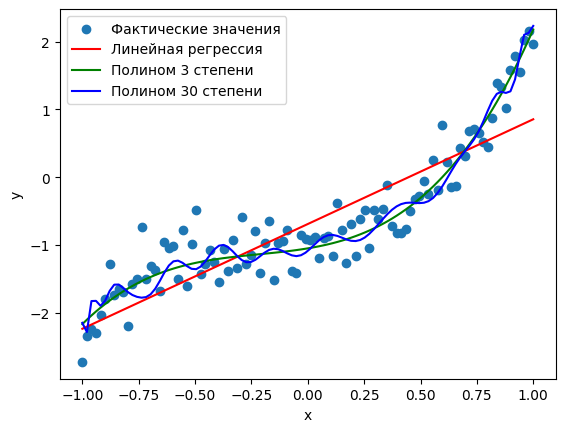

In [24]:
plt.scatter(x_data_test, y_data_test, label='Фактические значения')
plt.plot(x_data_test, preds_linear, color='red', label='Линейная регрессия')
plt.plot(x_data_test, preds_poly_3, color='green', label='Полином 3 степени')
plt.plot(x_data_test, preds_poly_30, color='blue', label='Полином 30 степени')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

Очевидно, полином 3 степени проявляет себя существенно лучше.

При этом обратим внимание: ошибка полинома 30 степени на тренировочной выборке самая низкая. А вот на тестовой выборке его результат уже сильно хуже.
> **В этом и состоит переобучение - модель очень хорошо подстраивается под тренировочный набор данных, но не даёт качественных результатов в реальных условиях.**

Поэтому использование тестовой выборки - один из основных способов отслеживания переобучения.

В идеале мы хотим построить модель, которая точно описывает зависимости в тренировочных данных и хорошо работает на неизвестных (тестовых). К сожалению, обычно это невозможно идеально сделать одновременно.

## 🟢 3. Регуляризация

Модель множественной регрессии предполагает **отсутствие сильной мультиколлинеарности** между признаками. Высокая корреляция делает один признак избыточным, усложняет модель и повышает дисперсию коэффициентов, снижая её способность к обобщению и увеличивая риск переобучения.


interval columns not set, guessing: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'sqft_living15', 'sqft_lot15']


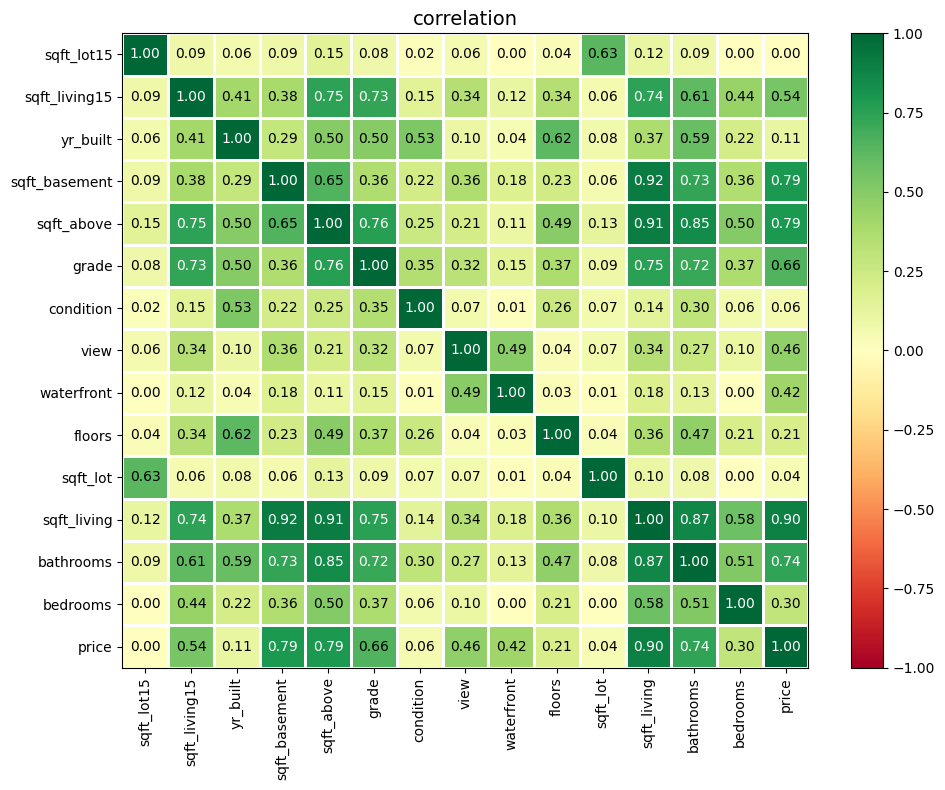

In [25]:
corr_matrix = phik_matrix(df)
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

Видим, что между двумя признаками оказалась высокая корреляция.

Что тут можно сделать?
- Удалить один признак из такой пары:
- Попробовать применить **регуляризацию**.

Методы регуляризации работают путем добавления штрафных коэффициентов к исходной функции потерь модели таким образом, что высокие значения коэффициентов снижаются. А признаки с очень низкими значениями коэффициентов (после штрафования) могут быть вообще отброшены. Это помогает уменьшать сложность модели, а также **снижает риск переобучения** путём уменьшения сложности модели.

**Штраф** — это дополнительное неотрицательное слагаемое в выражении для функции потерь, которое специально повышает ошибку.  За счёт этого слагаемого метод оптимизации будет находить не истинный минимум функции потерь, а псевдоминимум.

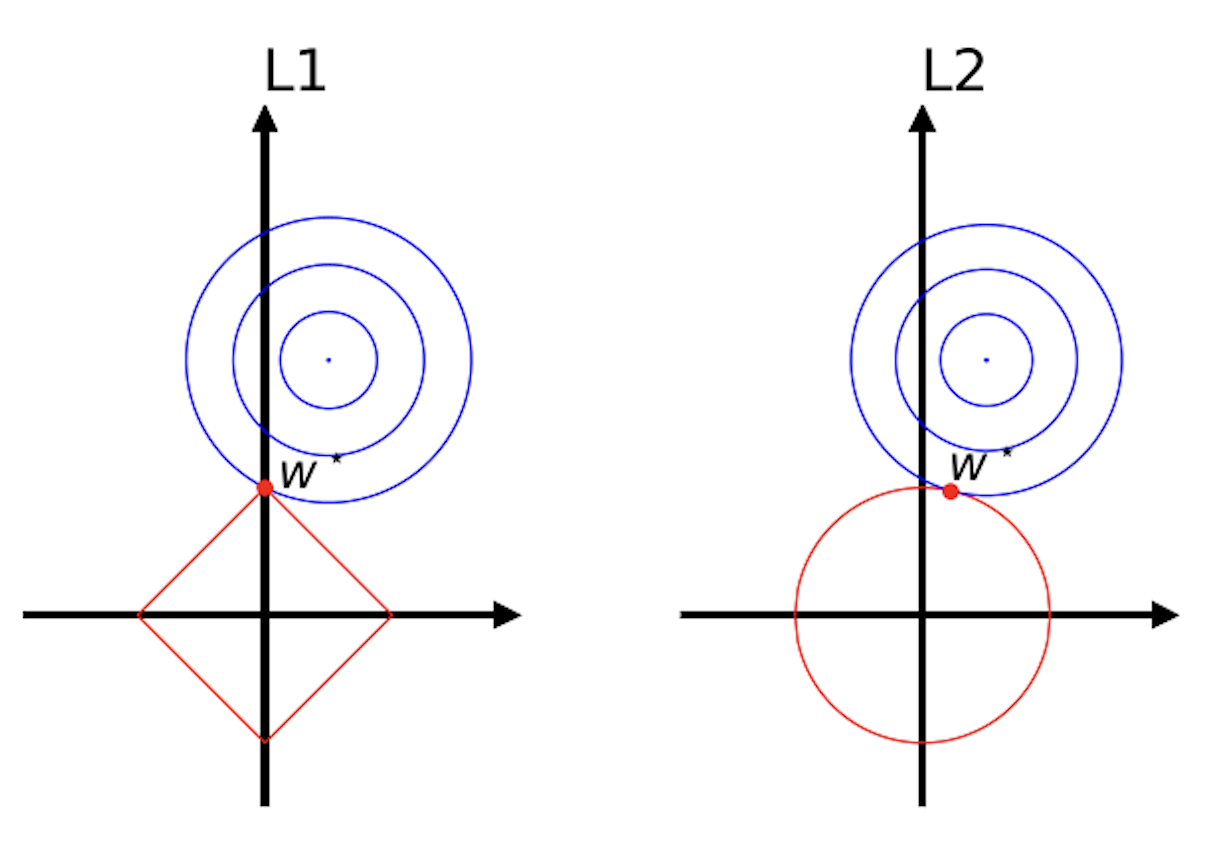

Существует множество методов регуляризации, из которых мы обсудим три наиболее часто используемых, а именно: `Rigde`, `Lasso` и `ElasticNet`.




> Если мы используем регуляризацию, то масштабирование признаков становится ещё более важным. Регуляризация накладывает штрафы на величины коэффициентов, и если признаки не отмасштабированы, модель может неправильно оценивать их важность.



### L1 (Lasso)

L1-регуляризация добавляет к функции потерь сумму модулей коэффициентов:

$$L1(w) = MSE + \lambda \sum_{i=1}^{n} |w_i|$$

Параметр $\lambda$ (alpha) регулирует силу штрафа: большое значение обнуляет ненужные коэффициенты, уменьшая сложность модели и риск переобучения. При $\lambda=0$ это обычная линейная регрессия.

Далее можно перебрать разные значения alpha, обучая Lasso, и оценить метрики на train и validation.


In [26]:
# Создаем список из 20 возможных значений от 0 до 2000
alpha_list = np.linspace(0, 2000, 20)

# Создаём пустые списки, в которые будем добавлять результаты
train_scores = []
test_scores = []

for alpha in tqdm(alpha_list):
    # Создаём объект класса линейной регрессии с L1-регуляризацией
    lasso_lr_poly = Lasso(alpha=alpha)
    # Обучаем модель
    lasso_lr_poly.fit(X_train_poly, y_train)
    # Делаем предсказание для тренировочной выборки
    y_train_predict_poly = lasso_lr_poly.predict(X_train_poly)
    # Делаем предсказание для тестовой выборки
    y_test_predict_poly = lasso_lr_poly.predict(X_test_poly)
    # Рассчитываем коэффициенты детерминации для двух выборок и добавляем их в списки
    train_scores.append(r2_score(y_train, y_train_predict_poly))
    test_scores.append(r2_score(y_test, y_test_predict_poly))

100%|██████████| 20/20 [01:24<00:00,  4.20s/it]


В результате выполнения данного кода в списках train_scores и test_scores появятся 20 различных значений $R^2$ на тренировочной и валидационных выборках. Построим линейные графики, которые покажут, как меняется метрика в зависимости от alpha:

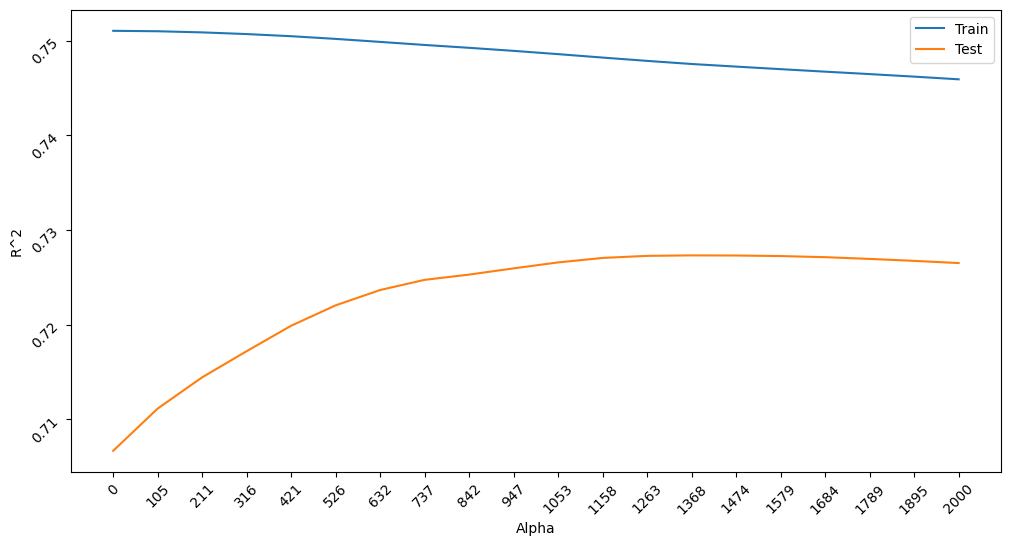

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(alpha_list, train_scores, label='Train')
plt.plot(alpha_list, test_scores, label='Test')
plt.xlabel('Alpha')
plt.ylabel('R^2')
plt.xticks(alpha_list)
plt.tick_params(rotation=45)
plt.legend()
plt.show()

Теперь мы можем подобрать оптимальное значение параметра alpha. Нам нужна такая точка на оси абсцисс, при которой на тестовой выборке наблюдается максимальная метрика на тесте.

In [28]:
# Находим максимальный R2-score для тренировочной выборки и соответствующее alpha
max_train_score_index = np.argmax(train_scores)
max_train_alpha = alpha_list[max_train_score_index]
print(f"Максимальный R2-score для тренировочной выборки: {train_scores[max_train_score_index]} при alpha: {max_train_alpha}")

# Находим максимальный R2-score для тестовой выборки и соответствующее alpha
max_test_score_index = np.argmax(test_scores)
max_test_alpha = alpha_list[max_test_score_index]
print(f"Максимальный R2-score для тестовой выборки: {test_scores[max_test_score_index]} при alpha: {max_test_alpha}")

Максимальный R2-score для тренировочной выборки: 0.7510597208143783 при alpha: 0.0
Максимальный R2-score для тестовой выборки: 0.727332950506155 при alpha: 1368.421052631579


Теперь проверим на тесте:

In [29]:
lasso_lr_poly = Lasso(alpha=1368.421052631579)

# Обучаем модель
lasso_lr_poly.fit(X_train_poly, y_train)

# Делаем предсказание для тренировочной выборки
y_train_predict_poly = lasso_lr_poly.predict(X_train_poly)

# Делаем предсказание для тестовой выборки
y_test_predict_poly = lasso_lr_poly.predict(X_test_poly)

# Рассчитываем коэффициент детерминации для двух выборок
print(f"R^2 на тренировочной выборке: {r2_score(y_train, y_train_predict_poly)}")
print(f"R^2 на тестовой выборке: {r2_score(y_test, y_test_predict_poly)}")

R^2 на тренировочной выборке: 0.747553437816897
R^2 на тестовой выборке: 0.727332950506155


Также можем посмотреть на значения коэффициентов после регулязирации. Большая часть коэффициентов обнулилась. Это значит, что признаки, которые соответствуют этим коэффициентам, не используются в прогнозе модели Lasso-регрессии.



In [30]:
lasso_lr_poly.coef_

array([-4.39273509e+03,  2.12269997e+04,  8.85352650e+04, -1.08357990e+04,
       -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.54697484e+04,
        1.21475062e+05,  0.00000000e+00,  1.61727588e+04, -7.66950963e+04,
        4.37751594e+04, -1.21760208e+04,  3.12240746e+02, -0.00000000e+00,
       -2.02847137e+03,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -3.43945677e+02,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
       -5.65871506e+03, -3.85999916e+03,  4.90320077e+01,  0.00000000e+00,
        0.00000000e+00,  2.11309256e+04, -1.29592975e+03, -2.06422768e+02,
       -0.00000000e+00,  1.14100947e+03, -3.65906244e+02,  9.73143613e+03,
        0.00000000e+00,  0.00000000e+00,  1.09296217e+03, -0.00000000e+00,
       -0.00000000e+00,  1.01467469e+04, -1.23262876e+04, -0.00000000e+00,
        1.08367687e+04,  0.00000000e+00, -0.00000000e+00,  2.44127738e+04,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -1.70796643e+03,  

Lasso (L1-регуляризацию) следует использовать, когда есть несколько характеристик с высокой предсказательной способностью, а остальные бесполезны. Она обнуляет бесполезные характеристики и оставляет только подмножество переменных.


### L2 (Ridge)

Она же регуляризация Тихонова — добавление к функции потерь суммы квадратов коэффициентов, умноженных на коэффициент регуляризации:

$$L2(w) = MSE + \lambda * \sum_{i=1}^{n} w_i^2$$

Признаки опять же должны быть стандартизованы для одинаковых штрафов относительно друг друга!

Ridge технически проще вычисляется, чем Lasso.

In [31]:
alpha_list = np.linspace(0, 2000, 20)

# Создаём пустые списки, в которые будем добавлять результаты
train_scores = []
test_scores = []

for alpha in tqdm(alpha_list):
    # Создаём объект класса линейной регрессии с L1-регуляризацией
    ridge_lr_poly = Ridge(alpha=alpha)
    # Обучаем модель
    ridge_lr_poly.fit(X_train_poly, y_train)
    # Делаем предсказание для тренировочной выборки
    y_train_predict_poly = ridge_lr_poly.predict(X_train_poly)
    # Делаем предсказание для тестовой выборки
    y_test_predict_poly = ridge_lr_poly.predict(X_test_poly)
    # Рассчитываем коэффициенты детерминации для двух выборок и добавляем их в списки
    train_scores.append(r2_score(y_train, y_train_predict_poly))
    test_scores.append(r2_score(y_test, y_test_predict_poly))

100%|██████████| 20/20 [00:00<00:00, 41.32it/s]


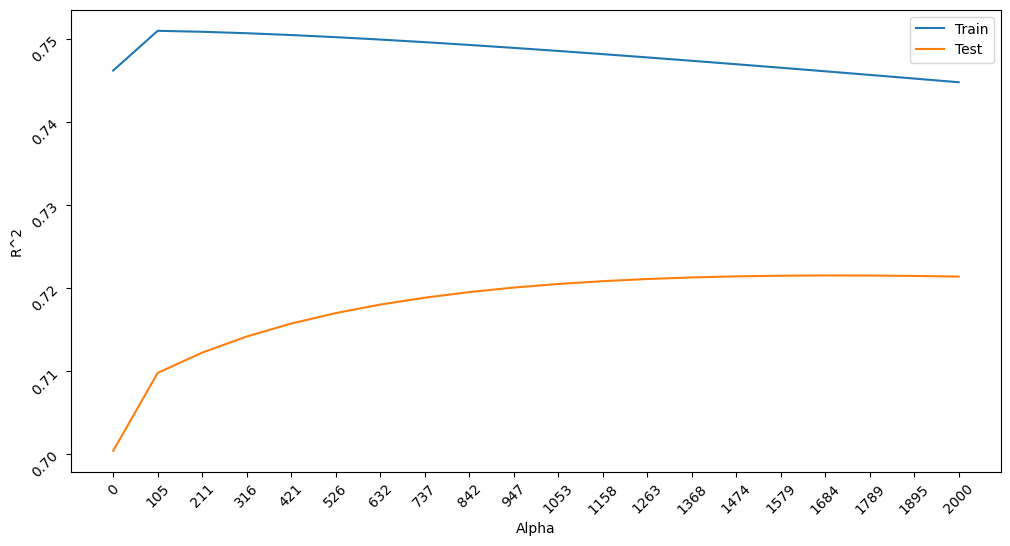

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(alpha_list, train_scores, label='Train')
plt.plot(alpha_list, test_scores, label='Test')
plt.xlabel('Alpha')
plt.ylabel('R^2')
plt.xticks(alpha_list)
plt.tick_params(rotation=45)
plt.legend()
plt.show()

In [33]:
# Находим максимальный R2-score для тренировочной выборки и соответствующее alpha
max_train_score_index = np.argmax(train_scores)
max_train_alpha = alpha_list[max_train_score_index]
print(f"Максимальный R2-score для тренировочной выборки: {train_scores[max_train_score_index]} при alpha: {max_train_alpha}")

# Находим максимальный R2-score для тестовой выборки и соответствующее alpha
max_test_score_index = np.argmax(test_scores)
max_test_alpha = alpha_list[max_test_score_index]
print(f"Максимальный R2-score для тестовой выборки: {test_scores[max_test_score_index]} при alpha: {max_test_alpha}")

Максимальный R2-score для тренировочной выборки: 0.7510159874358705 при alpha: 105.26315789473684
Максимальный R2-score для тестовой выборки: 0.7215485739873087 при alpha: 1684.2105263157894


In [34]:
ridge_lr_poly = Ridge(alpha=1684.2105263157894)

# Обучаем модель
ridge_lr_poly.fit(X_train_poly, y_train)

# Делаем предсказание для тренировочной выборки
y_train_predict_poly = ridge_lr_poly.predict(X_train_poly)

# Делаем предсказание для тестовой выборки
y_test_predict_poly = ridge_lr_poly.predict(X_test_poly)

# Рассчитываем коэффициент детерминации для двух выборок
print(f"R^2 на тренировочной выборке: {r2_score(y_train, y_train_predict_poly)}")
print(f"R^2 на тестовой выборке: {r2_score(y_test, y_test_predict_poly)}")

R^2 на тренировочной выборке: 0.7461400366373763
R^2 на тестовой выборке: 0.7215485739873087


In [35]:
ridge_lr_poly.coef_

array([ -2375.72809582,  22965.86553233,  47692.6720339 , -12556.15961422,
          142.9472653 ,    325.01273835,   3742.02202565,  18149.55679771,
        97070.15461229,  34569.04093951,  33853.59027733, -57819.86002913,
        45559.10337486, -11019.07628711,    336.99809331,   -640.0262711 ,
        -6012.84426958,   2878.07762889,   2453.03166377,    323.51592436,
        -2816.29573767,    927.95667093,   1155.97379564,  -3133.95590414,
        -6562.16070899,  -5990.49623392,   6463.20006285,   2157.16022043,
          986.63419638,  12239.58042397,  -5733.91657606,  -6767.91102197,
         -526.89473481,   4037.3796941 ,  -1793.57045271,  11853.36236683,
        10849.91066134,   4981.16349222,   5215.23956543,  -8486.76149623,
         3202.99196938,   4488.06545593,  -7733.85061987,  -2030.4060564 ,
         8404.55912991,   -509.67828105,  -1333.05428702,  12393.13239387,
         5453.93820403,   -938.08288266,  -3443.00904093,  -1862.0260815 ,
        -1847.30634835,  


Ridge-регрессия работает лучше в том случае, когда коэффициенты примерно одинакового размера, то есть все признаки влияют на целевую переменную примерно одинаково.

### Elastic Net

Регуляризация Elastic Net сочетает в себе одновременно Lasso и Ridge-регуляризации.

Функция потерь имеет два важных гиперпараметра: `alpha` и `l1_ratio`.
- Альфа в случае регуляризации Elastic Net — это константа, которая умножается на штрафы и для L1 (Lasso), и для L2 (Ridge).
- Гиперпараметр `l1_ratio` называется параметром смешивания, `0 <= l1_ratio <= 1`.

Когда `l1_ratio` равен 1, это означает, что доля L1 (Lasso) равна 100%, а доля L2 (Ridge) равна 0% - то есть просто делается Lasso-регуляризация. Аналогично, когда `l1_ratio` равно 0, это то же самое, что обычная Ridge-регуляризация.

Проделаем простейший процесс подбора этих двух гиперпараметров в обычных циклах.

In [36]:
# Создаём список из 20 возможных значений от 0 до 1 для l1_ratio
l1_ratio_list = np.linspace(0, 1, 20)

# Создаём пустые списки, в которые будем добавлять результаты
# Инициализируем переменные для сохранения лучших результатов
best_train_score = -np.inf
best_test_score = -np.inf
best_train_params = (None, None)
best_test_params = (None, None)

for l1_ratio in tqdm(l1_ratio_list):
  # Создаём список из 20 возможных значений от 0 до 2000 для alpha
  alpha_list = np.linspace(0, 2000, 20)

  for alpha in alpha_list:
    # Создаём объект класса линейной регрессии с elastic net регуляризацией
        elastic_net_lr = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        # Обучаем модель
        elastic_net_lr.fit(X_train_poly, y_train)

        # Делаем предсказание для тренировочной выборки
        y_train_predict_poly = elastic_net_lr.predict(X_train_poly)
        y_train_score = r2_score(y_train, y_train_predict_poly)

        # Делаем предсказание для тестовой выборки
        y_test_predict_poly = elastic_net_lr.predict(X_test_poly)
        y_test_score = r2_score(y_test, y_test_predict_poly)

        if y_train_score > best_train_score:
            best_train_score = y_train_score
            best_train_params = (alpha, l1_ratio)
        if y_test_score > best_test_score:
            best_test_score = y_test_score
            best_test_params = (alpha, l1_ratio)

100%|██████████| 20/20 [08:24<00:00, 25.22s/it]


In [37]:
# Выводим лучшие результаты
print(f'Лучший R^2 для тренировочной выборки: {best_train_score}, alpha: {best_train_params[0]}, l1_ratio: {best_train_params[1]}')
print(f'Лучший R^2 для тестовой выборки: {best_test_score}, alpha: {best_test_params[0]}, l1_ratio: {best_test_params[1]}')

Лучший R^2 для тренировочной выборки: 0.7510597208143783, alpha: 0.0, l1_ratio: 0.0
Лучший R^2 для тестовой выборки: 0.727332950506155, alpha: 1368.421052631579, l1_ratio: 1.0


Регуляризацию, конечно, совсем не обязательно применять только при генерации полиномиальных признаков.

*На практике не всегда очевидно, какой из методов регуляризации сработает лучше. Выход — пробовать разные подходы и сравнивать результаты.*

